### Clustering

- I need to do some clustering algos and see which does best
- Select which columns to use


What am I hoping clustering will do?
- Make more "like" groupings of school districts based on certain demographic data. 
- I believe the clusters will still have normal distribution curves, and linear relationships.

What columns are allowed in clustering -- For this one I want to make two selection types, one with ethnic data and one without as some grants or other funding does not like considering that information when benchmarking
- Eco-dis %
- student body size
- average teacher pay
- Ethnic homogeneity with students and staff
- Staff size


What makes up a row?
- a row will be made up of one school with all of its given metrics
- I want to only select schools who's metrics have not drastically changed in the past 3 years. What is why I have the historical data as I believe if a school has hd drastic changes they will be an outlier and throw off the model. for the school years data I will want to use the 2024 numbers as I believe any miss calculations have been adjusted by then (not sure if they even upload corrections but don't feel like looking as of now).
- I will need to normalize all the numbers down to aq 0 to 1 scale so large differences aren't causing issues.

I would also like to run an algo to see how strongly any one variable seems to be in relation to the overall outcomes

Right now, my data probably looks like a few loosely clouds semi clustered and overlapping because nothing is normalized and teacher pay of $40,000 and eco-dis count of 270 out of 3000 students are working together to make the a shape but are working on completely different scales, so I need an approach that with a very loss clustering algo until I clean further.

In [90]:
# Importing libraries
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

In [91]:
# loading in data sets
student_df = pd.read_csv(r"Clean Datasets\student_analysis_df.csv", dtype={'YearDistrict ID': str, 'DISTRICT': str, 'Year': str})
staff_df = pd.read_csv(r"Clean Datasets\staff_analysis_df.csv", dtype={'YearDistrict ID': str, 'DISTRICT': str, 'Year': str})


## Exploratory Clustering

- find rates for student and staff data
- Z-Score normalize
- 

- Stretch goal: Principal Components Analysis (PAC) on eco-dis, homeless


In [92]:
# Defining columns to keep
student_col_to_keep = ['YearDistrict ID', 'DISTRICT', 'Year', 'All Students Count', 'Special Ed Count',
                        'Bilingual/ESL Count', 'Career & Technical Education Count',
                        'Gifted & Talented Count', 'EB/EL Count', 'Econ Disadv Count',
                        'Non-Educationally Disadv Count', 'At Risk Count',
                        'American Indian Count', 'Asian Count', 'Pacific Islander Count',
                        'Two or More Races Count', 'African American Count', 'Hispanic Count',
                        'White Count', 'Male Count', 'Female Count',
                        'Section 504 Count', 'Title I Count', 'Homeless Count',
                        'Immigrant Count', 'Migrant Count',
                        'Total Students with Disabilities Count',
                        'Intellectual Disabilities Count', 'Physical Disabilities Count',
                        'Behavioral Disabilities Count', 'District Name', 'County ID',
                        'County Name', 'Region', 'Charter Flag', 'DFLALTED']

staff_col_to_keep = [   'YearDistrict ID', 'Year', 'DISTRICT',       
                        'Teacher Total Full Time Equiv Count',
                        'Support Total Full Time Equiv Count',
                        'School Admin Total Full Time Equiv Count',
                        'Central Admin Total Full Time Equiv Count',
                        'Educ Aide Total Full Time Equiv Count',
                        'Teacher Total Base Salary Total', 'Support Total Base Salary Total',
                        'School Admin Total Base Salary Total',
                        'Teacher Beginning Full Time Equiv Count',
                        'Teacher 1-5 Years Full Time Equiv Count',
                        'Teacher 6-10 Years Full Time Equiv Count',
                        'Teacher 11-20 Years Full Time Equiv Count',
                        'Teacher 21-30 Years Full Time Equiv Count',
                        'Teacher > 30 Years Full Time Equiv Count',
                        'Teacher Beginning Base Salary Total',
                        'Teacher 1-5 Years Base Salary Total',
                        'Teacher 6-10 Years Base Salary Total',
                        'Teacher 11-20 Years Base Salary Total',
                        'Teacher 21-30 Years Base Salary Total',
                        'Teacher > 30 Years Base Salary Total',
                        'Teacher No Degree Full Time Equiv Count',
                        'Teacher BA Degree Full Time Equiv Count',
                        'Teacher MS Degree Full Time Equiv Count',
                        'Teacher PH Degree Full Time Equiv Count',
                        'Teacher American Indian Full Time Equiv Count',
                        'Teacher Pacific Islander Full Time Equiv Count',
                        'Teacher Asian Full Time Equiv Count',
                        'Teacher African American Full Time Equiv Count',
                        'Teacher Hispanic Full Time Equiv Count',
                        'Teacher White Full Time Equiv Count',
                        'Teacher Two or more races Full Time Equiv Count',
                        'Teacher Male Full Time Equiv Count',
                        'Teacher Female Full Time Equiv Count',
                        'Teacher Regular Program Full Time Equiv Count',
                        'Teacher Career & Technical Prgms Full Time Equiv Count',
                        'Teacher Bilingual Program Full Time Equiv Count',
                        'Teacher Compensatory Program Full Time Equiv Count',
                        'Teacher Gifted & Talented Program Full Time Equiv Count',
                        'Teacher Special Education Full Time Equiv Count',
                        'Teacher Other Full Time Equiv Count', 'Teacher Turnover Numerator',
                        'Teacher Turnover Denominator', 'Principal Experience Total',
                        'Principal Tenure Total', 'Assistant Principal Experience Total',
                        'Assistant Principal Tenure Total',
                        'Teacher Incentive Allotment Master Head Count',
                        'Teacher Incentive Allotment Exemplary Head Count',
                        'Teacher Incentive Allotment Recognized Head Count']

In [93]:
# FILTER: filtering data frames down to columns defined to keep
student_df_1 = student_df[student_col_to_keep]
staff_df_1 = staff_df[staff_col_to_keep]

# student_df_1
# staff_df_1

In [94]:
# Select Student Numerators
student_numerators = [ 'Special Ed Count', 'Bilingual/ESL Count',
                        'Career & Technical Education Count', 'Gifted & Talented Count',
                        'EB/EL Count', 'Econ Disadv Count', 'Non-Educationally Disadv Count',
                        'At Risk Count', 'American Indian Count', 'Asian Count',
                        'Pacific Islander Count', 'Two or More Races Count',
                        'African American Count', 'Hispanic Count', 'White Count', 'Male Count',
                        'Female Count', 'Section 504 Count', 'Title I Count',
                        'Homeless Count', 'Immigrant Count', 'Migrant Count',
                        'Total Students with Disabilities Count',
                        'Intellectual Disabilities Count', 'Physical Disabilities Count',
                        'Behavioral Disabilities Count']

### Beta-Binomial Model - Smoothed Rate Function (Explore shrinkage estimation and  smoothing tequinices)

Beta-Binomial shrinkage

Notes: A discovery happened as I was exploring my data sets post z-score calculations, and that was that some districts were in the range of (10, 9), but when I just open the data set, it looks like most of the numbers are in the range (1, -1). While I did not clearly know why, from what I have learned so far about statistical modeling, I could tell such huge ranges did not make sense, so I looked at the affected columns.

When I started exploring the affected columns, I noticed that often the cell that I calculated off of for example, the number of teachers with 30+ years of experience it may have been zero because it was a small district. Initially, I wanted to keep the data set whole. But I knew I could not just make the values NaN, as that would affect downstream statistical values by either creating them inaccurately or removing them from the data set. I wanted to try and keep as many rows or values as possible, because otherwise, I'd have to remove them from multiple years, and that would eventually shrink my data set to what I believe will be unusable because I'm only working within a thousand or so data points.

In school districts with small populations, even a single data point can create an extreme outlier. For example, in a district of only five teachers, one teacher constitutes 20% of the total; that would likely create a huge statistical anomaly in my calculations down the line. To prevent these small-population "flukes" from distorting our model, we apply a smoothing technique. This approach provides "statistical help" to smaller districts by pulling their rates toward the state average, ensuring that their limited data size doesn't create misleading extremes that skew the overall analysis.
 

In [95]:
# FUNCTION: Beta binomial shrinkage/smoothing

def bbm_smoothing(df, trials, successes, fake_trials=100):
    """
    This is a beta-binomial smoothing model, which is a more sophisticated way of determining a rate. 
    In situations with small sample sizes like a school district with only 10 teachers the small headcount 
    means theres a lower probability of seeing someone with 30-plus years of experience. Conversely, if a 
    small district happens to have 3 teachers in that category, it creates an extreme percentage that is 
    statistically unlikely but possible. My goal is to support these smaller districts by smoothing those values, ensuring 
    they aren't penalized by extreme outliers when we group or benchmark them later on.

    df: DataFrame
    Trial: In this case, the labor market of teachers in a given year.
    Success: Teachers with 30+ years of experience.
    fake_trials: How much assistance we give schools when calculating the smoothed rate.
    """
    
    # If we are just smoothing one column we need to make it a list item for the function to handel it
    if isinstance(successes, str):
        success = [successes]

    # Compute the smoothed rate for each column we are looking at.
    for success in successes:
        df[success].fillna(0)
        n_trials = df.groupby('Year')[trials].transform('sum')      # Total number of trials
        k_successes = df.groupby('Year')[success].transform('sum')  # Total number of events that meet our criteria
        probability = k_successes/n_trials                          # Rate of successes to trials
        fake_successes = probability*fake_trials                    # Alpha number of added fake successes

        df[success+"_bbm_smoothed"] = (df[success] + fake_successes)/(df[trials].fillna(0) + fake_trials)

    
    return df


In [96]:
# FUNCTION: Calculating z score
def zscore(df: pd.DataFrame):
    """
    Calculates the z score of a column grouped by year
    df: DataFrame
    """
    for col in df.columns:
        if "smoothed" in col:
            z_col = col+"_ZScore"
            df[z_col] = (
                df[col] -
                df.groupby('Year')[col].transform('mean')
            ) / df.groupby('Year')[col].transform('std')

    return df

In [97]:
student_df_1 = bbm_smoothing(student_df_1,'All Students Count', student_numerators) 
student_df_1 = zscore(student_df_1)
student_df_1

,YearDistrict ID,DISTRICT,Year,All Students Count,Special Ed Count,Bilingual/ESL Count,Career & Technical Education Count,Gifted & Talented Count,EB/EL Count,Econ Disadv Count,...,Female Count_bbm_smoothed_ZScore,Section 504 Count_bbm_smoothed_ZScore,Title I Count_bbm_smoothed_ZScore,Homeless Count_bbm_smoothed_ZScore,Immigrant Count_bbm_smoothed_ZScore,Migrant Count_bbm_smoothed_ZScore,Total Students with Disabilities Count_bbm_smoothed_ZScore,Intellectual Disabilities Count_bbm_smoothed_ZScore,Physical Disabilities Count_bbm_smoothed_ZScore,Behavioral Disabilities Count_bbm_smoothed_ZScore
0,2017001902,001902,2017,576,82,3,150.0,55,3,192,...,NaN,NaN,NaN,NaN,NaN,NaN,1.958757,3.186404,0.518631,-0.474600
1,2017001903,001903,2017,1267,139,19,299.0,39,19,673,...,NaN,NaN,NaN,NaN,NaN,NaN,0.786300,0.914699,0.767885,-0.296357
2,2017001904,001904,2017,846,75,18,229.0,59,18,446,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.089180,0.565687,-1.295011,-0.348047
3,2017001906,001906,2017,377,37,6,118.0,24,6,172,...,NaN,NaN,NaN,NaN,NaN,NaN,0.242339,1.850979,NaN,NaN
4,2017001907,001907,2017,3453,303,516,1222.0,93,557,2587,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.125151,-0.313232,-0.566824,-0.033027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10327,2025252902,252902,2025,225,42,4,73.0,3,4,140,...,-0.217253,0.308078,0.487047,-0.511397,-0.246686,-0.273969,0.463742,0.262527,-0.313866,0.450044
10328,2025252903,252903,2025,689,145,98,202.0,27,98,383,...,-0.753747,0.778016,-0.197302,0.455078,1.558280,-0.310867,1.210529,-0.363964,3.418337,NaN
10329,2025253901,253901,2025,3282,566,1072,940.0,233,981,2917,...,-0.346638,-0.135628,0.852533,2.391519,-0.367843,0.654155,0.340635,0.660819,-0.477839,-0.826590
10330,2025254901,254901,2025,1635,298,40,575.0,127,41,1329,...,-0.105090,0.351827,0.815648,1.657988,-0.684166,0.250958,0.582403,0.226908,0.075115,0.133402


In [98]:
# Defining staff numerators
teacher_ep_numerator  =['Teacher Beginning Full Time Equiv Count',
                        'Teacher 1-5 Years Full Time Equiv Count',
                        'Teacher 6-10 Years Full Time Equiv Count',
                        'Teacher 11-20 Years Full Time Equiv Count',
                        'Teacher 21-30 Years Full Time Equiv Count',
                        'Teacher > 30 Years Full Time Equiv Count']

teacher_pay_numerator = ['Teacher Beginning Base Salary Total',
                        'Teacher 1-5 Years Base Salary Total',
                        'Teacher 6-10 Years Base Salary Total',
                        'Teacher 11-20 Years Base Salary Total',
                        'Teacher 21-30 Years Base Salary Total',
                        'Teacher > 30 Years Base Salary Total']

teacher_edu_numerator = ['Teacher No Degree Full Time Equiv Count',
                        'Teacher BA Degree Full Time Equiv Count',
                        'Teacher MS Degree Full Time Equiv Count',
                        'Teacher PH Degree Full Time Equiv Count',]

teacher_eth_numerator = ['Teacher American Indian Full Time Equiv Count',
                        'Teacher Pacific Islander Full Time Equiv Count',
                        'Teacher Asian Full Time Equiv Count',
                        'Teacher African American Full Time Equiv Count',
                        'Teacher Hispanic Full Time Equiv Count',
                        'Teacher White Full Time Equiv Count',
                        'Teacher Two or more races Full Time Equiv Count',]

In [99]:
#staff_df_1.fillna(0, inplace=True)
staff_df_2 = bbm_smoothing(staff_df_1,'Teacher Total Full Time Equiv Count', teacher_ep_numerator)
#staff_df_2 = bbm_smoothing(staff_df_2, 'Teacher Total Full Time Equiv Count', teacher_edu_numerator,)
#staff_df_2 = bbm_smoothing(staff_df_2, 'Teacher Total Full Time Equiv Count', teacher_eth_numerator,)
# staff_df_2 = bbm_smoothing(staff_df_2, 'Teacher Total Base Salary Total', 'Teacher Total Full Time Equiv Count')
# staff_df_2 = bbm_smoothing(staff_df_2, teacher_pay_numerator, 'Teacher Total Base Salary Total')

staff_df_2 = zscore(staff_df_2)


In [100]:
# TODO: Figure out nan to 0 issue
# smoothing teacher comp

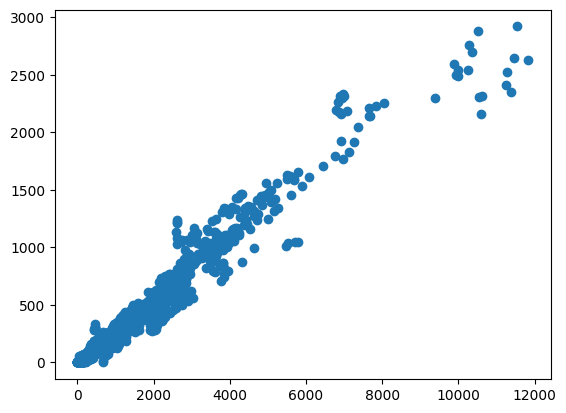

In [101]:
# Select Teacher Numerators
plt.scatter(staff_df_2['Teacher Total Full Time Equiv Count'],staff_df_2['Teacher MS Degree Full Time Equiv Count'] )

## Clustering Algorithms

DBSCAN - (Density-Based Spatial Clustering of Applications with Noise) 